# Anomaly Clustering

This notebook clusters flagged anomalies across the three detection models:

- **Transformer + OC-SVM** (general anomaly detection via negated OC-SVM decision function)
- **PNN** with spoofing gain (detects spoofing-type manipulation only)
- **PRAE** with Rolling FDR (general anomaly detection via reconstruction error)

The core hypothesis is that PNN captures spoofing events whereas OC-SVM and PRAE detect a broader class of manipulations. Clustering the anomaly score vectors reveals the latent structure of detected events.

**Workflow:**
1. Score all test samples with each model using the same pipeline as notebook 3.
2. Collect samples flagged as anomalous by at least one model.
3. Cluster in normalised score space (3-dimensional) using K-Means; select k by silhouette score.
4. Validate with DBSCAN and hierarchical clustering.
5. Reduce to 2D via PCA and t-SNE for visualisation.
6. Profile each cluster: model agreement rates, time-of-day distribution, dominant features.

In [1]:
import os
import sys
import glob
import logging
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
from torch.utils.data import DataLoader, TensorDataset


sys.path.insert(0, os.path.abspath(".."))

from detection.data.loaders import create_sequences
from detection.models import hybrid, pnn as pnn_module, prae as prae_module
from detection.models.transformer import BottleneckTransformer
from detection.spoofing.gain import compute_spoofing_gains_batch
from detection.thresholds.rfdr import RollingFalseDiscoveryRate

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)
logger = logging.getLogger(__name__)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## Configuration

In [2]:
DATA_DIR    = os.path.join("..", "data", "processed", "TOTF.PA-book")
RESULTS_DIR = os.path.join("..", "results")
MODEL_TYPES = ["transformer_ocsvm", "pnn", "prae"]

SEQ_LENGTH  = 25
BATCH_SIZE  = 64
WARMUP_STEPS = 3000

LOB_COLUMNS = [
    f"{side}-{typ}-{lvl}"
    for lvl in range(1, 11)
    for side, typ in [
        ("bid", "price"), ("bid", "volume"),
        ("ask", "price"), ("ask", "volume"),
    ]
]

# Spoofing gain parameters (PNN)
SPOOF_Q       = 4500
SPOOF_q       = 100
SPOOF_DELTA_A = 0.0
SPOOF_DELTA_B = 0.01
SPOOF_FEES    = {"maker": 0.0, "taker": 0.05}

# RFDR parameters (PRAE)
RFDR_WINDOW = 500
RFDR_ALPHA  = 0.05

# Trading periods (hours since midnight, CET)
PERIODS = {
    "1st_hour":        (9.0,  10.0),
    "rest_of_morning": (10.0, 12.0),
    "afternoon":       (12.0, 15.5),
    "american_open":   (15.5, 17.5),
}

# Clustering
KMEANS_K_RANGE = range(2, 7)
RANDOM_STATE   = 42

FILES      = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))
TEST_FILES = [FILES[3]]
print(f"Test file: {os.path.basename(TEST_FILES[0])}")

Test file: 2015-01-07-TOTF.PA-book.parquet


## Helper Functions

In [3]:
def load_processed(filepath):
    full     = pd.read_parquet(filepath)
    meta_cols = ["xltime"] + [c for c in LOB_COLUMNS if c in full.columns]
    meta_set  = set(meta_cols)
    feat_cols = [c for c in full.columns if c not in meta_set]
    return full[meta_cols], full[feat_cols]


def get_time_frac(df):
    base_date = np.floor(df["xltime"].values)
    return df["xltime"].values - base_date


def assign_period(time_frac_arr):
    labels = np.full(len(time_frac_arr), "unknown", dtype=object)
    for name, (open_h, close_h) in PERIODS.items():
        mask = (time_frac_arr >= open_h / 24.0) & (time_frac_arr < close_h / 24.0)
        labels[mask] = name
    return labels


def build_model(model_type, num_features, weights_path):
    if model_type == "transformer_ocsvm":
        transformer = BottleneckTransformer(
            num_features=num_features, model_dim=64, num_heads=4,
            num_layers=2, representation_dim=128, sequence_length=SEQ_LENGTH,
        )
        transformer.load_state_dict(
            torch.load(weights_path, map_location=DEVICE, weights_only=True)
        )
        transformer.eval().to(DEVICE)
        ocsvm_path = weights_path.replace("_weights.pth", "_detector.pth")
        ocsvm = torch.load(ocsvm_path, map_location=DEVICE, weights_only=False) \
                if os.path.exists(ocsvm_path) else None
        return transformer, ocsvm

    elif model_type == "pnn":
        input_dim = SEQ_LENGTH * num_features
        model = pnn_module.PNN(input_dim=input_dim, hidden_dim=64).to(DEVICE)
        model.load_state_dict(
            torch.load(weights_path, map_location=DEVICE, weights_only=True)
        )
        model.eval()
        return model, None

    elif model_type == "prae":
        backbone = BottleneckTransformer(
            num_features=num_features, model_dim=64, num_heads=4,
            num_layers=2, representation_dim=128, sequence_length=SEQ_LENGTH,
        )
        model = prae_module.PRAE(
            backbone_model=backbone, num_train_samples=1,
            lambda_reg=1.0, sigma=0.5,
        ).to(DEVICE)
        state_dict = torch.load(weights_path, map_location=DEVICE, weights_only=True)
        state_dict = {k: v for k, v in state_dict.items() if k != "mu"}
        model.load_state_dict(state_dict, strict=False)
        model.eval()
        return model, None

    raise ValueError(f"Unknown model type: {model_type}")

## Load Feature Names and Models

In [4]:
feature_names_map = {}
for mt in MODEL_TYPES:
    feat_path = os.path.join(RESULTS_DIR, f"{mt}_features.txt")
    if os.path.exists(feat_path):
        with open(feat_path) as fh:
            feature_names_map[mt] = [ln.strip() for ln in fh if ln.strip()]
    else:
        _, _tmp = load_processed(TEST_FILES[0])
        feature_names_map[mt] = _tmp.columns.tolist()
        del _tmp

for mt, fnames in feature_names_map.items():
    print(f"{mt}: {len(fnames)} features")

loaded_models   = {}
loaded_scalers  = {}

for model_type in MODEL_TYPES:
    feat_names   = feature_names_map[model_type]
    num_features = len(feat_names)
    weights_path = os.path.join(RESULTS_DIR, f"{model_type}_weights.pth")
    model, ocsvm = build_model(model_type, num_features, weights_path)
    loaded_models[model_type] = (model, ocsvm)

    scaler_path = os.path.join(RESULTS_DIR, f"{model_type}_scaler.pkl")
    loaded_scalers[model_type] = (
        joblib.load(scaler_path) if os.path.exists(scaler_path) else MinMaxScaler()
    )
    logger.info("Loaded %s (%d features).", model_type, num_features)

transformer_ocsvm: 89 features
pnn: 89 features
prae: 89 features


2026-03-12 18:26:06,155 | INFO | Loaded transformer_ocsvm (89 features).
2026-03-12 18:26:06,168 | INFO | Loaded pnn (89 features).
2026-03-12 18:26:06,239 | INFO | Loaded prae (89 features).


## Score Test Samples

Reproduce the scoring pipeline from notebook 3. Scores are the raw detection signals before any binary thresholding:

| Model | Score | Anomaly condition |
|-------|-------|-------------------|
| Transformer + OC-SVM | Negated OC-SVM decision function | score > 0 |
| PNN | Expected spoofing gain | gain > 0 |
| PRAE | Reconstruction error (RFDR-thresholded) | RFDR flag = 1 |

In [5]:
all_scores       = {mt: [] for mt in MODEL_TYPES}
all_preds        = {mt: [] for mt in MODEL_TYPES}
all_period_labels = []
all_feat_values   = []
day_boundaries    = [0]
day_names         = []

for test_file in TEST_FILES:
    day_name = os.path.basename(test_file)
    day_names.append(day_name)
    logger.info("Scoring %s", day_name)

    df_day, features_day = load_processed(test_file)
    time_frac_day   = get_time_frac(df_day)[:len(features_day)]
    period_labels   = assign_period(time_frac_day)
    spread_raw      = (df_day["ask-price-1"] - df_day["bid-price-1"]).values
    n_seq           = len(features_day) - SEQ_LENGTH

    all_period_labels.append(period_labels[SEQ_LENGTH: SEQ_LENGTH + n_seq])
    all_feat_values.append(
        features_day.iloc[SEQ_LENGTH: SEQ_LENGTH + n_seq].reset_index(drop=True)
    )

    for model_type in MODEL_TYPES:
        feat_names   = feature_names_map[model_type]
        scaler       = loaded_scalers[model_type]
        model, ocsvm = loaded_models[model_type]

        feat_df = features_day.copy()
        for col in feat_names:
            if col not in feat_df.columns:
                feat_df[col] = 0.0
        feat_df = feat_df[feat_names]

        scaled    = scaler.transform(feat_df.values.astype(np.float32)).astype(np.float32)
        sequences = create_sequences(scaled, SEQ_LENGTH)

        if model_type == "transformer_ocsvm":
            x_tensor = torch.tensor(sequences, dtype=torch.float32)
            loader   = DataLoader(TensorDataset(x_tensor, x_tensor),
                                  batch_size=BATCH_SIZE, shuffle=False)
            if ocsvm is not None:
                detector             = hybrid.TransformerOCSVM.__new__(hybrid.TransformerOCSVM)
                detector.transformer = model
                detector.ocsvm       = ocsvm
                scores               = detector.predict(loader)
            else:
                scores_list = []
                with torch.no_grad():
                    for batch in loader:
                        x   = batch[0].to(DEVICE)
                        rec = model(x)
                        scores_list.append(
                            torch.mean((x - rec) ** 2, dim=(1, 2)).cpu().numpy()
                        )
                scores = np.concatenate(scores_list)
            del x_tensor, loader
            preds = (scores > 0).astype(int)

        elif model_type == "pnn":
            target_col = "log_return"
            all_mu, all_sigma, all_alpha = [], [], []
            model.eval()
            with torch.no_grad():
                for start in range(0, len(sequences), BATCH_SIZE):
                    end    = min(start + BATCH_SIZE, len(sequences))
                    x_b    = torch.tensor(
                        np.ascontiguousarray(sequences[start:end]),
                        dtype=torch.float32,
                    ).reshape(end - start, -1).to(DEVICE)
                    mu, sigma, alpha = model(x_b)
                    all_mu.append(mu.cpu().numpy().flatten())
                    all_sigma.append(sigma.cpu().numpy().flatten())
                    all_alpha.append(alpha.cpu().numpy().flatten())

            mu_arr    = np.concatenate(all_mu)
            sigma_arr = np.concatenate(all_sigma)
            alpha_arr = np.concatenate(all_alpha)

            spread_seq = spread_raw[SEQ_LENGTH: SEQ_LENGTH + len(mu_arr)]
            if len(spread_seq) < len(mu_arr):
                spread_seq = np.pad(spread_seq,
                                    (0, len(mu_arr) - len(spread_seq)), mode="edge")
            spread_seq = np.where(np.abs(spread_seq) > 0, np.abs(spread_seq), 1e-4)

            scores = compute_spoofing_gains_batch(
                mu_arr, sigma_arr, alpha_arr, spread_seq,
                delta_a=SPOOF_DELTA_A, delta_b=SPOOF_DELTA_B,
                Q=SPOOF_Q, q=SPOOF_q,
                fees=SPOOF_FEES, side="ask",
            )
            preds = (scores > 0).astype(int)

        elif model_type == "prae":
            x_tensor = torch.tensor(sequences, dtype=torch.float32)
            loader   = DataLoader(TensorDataset(x_tensor, x_tensor),
                                  batch_size=BATCH_SIZE, shuffle=False)
            scores_list = []
            with torch.no_grad():
                for batch in loader:
                    x   = batch[0].to(DEVICE)
                    rec, _ = model(x, training=False)
                    scores_list.append(
                        torch.sum((x - rec) ** 2,
                                  dim=tuple(range(1, x.dim()))).cpu().numpy()
                    )
            scores = np.concatenate(scores_list)
            del x_tensor, loader

            rfdr  = RollingFalseDiscoveryRate(window_size=RFDR_WINDOW, alpha=RFDR_ALPHA)
            preds = np.zeros(len(scores), dtype=int)
            for i, s in enumerate(scores):
                is_anom, _ = rfdr.process_new_score(float(s))
                preds[i]   = int(is_anom)

        all_scores[model_type].append(scores)
        all_preds[model_type].append(preds)
        logger.info("  %s: %d / %d anomalies (%.2f%%)",
                    model_type, preds.sum(), len(preds), 100 * preds.mean())

    day_boundaries.append(day_boundaries[-1] + n_seq)

for mt in MODEL_TYPES:
    all_scores[mt] = np.concatenate(all_scores[mt])
    all_preds[mt]  = np.concatenate(all_preds[mt])

period_labels_seq = np.concatenate(all_period_labels)
feat_values_seq   = pd.concat(all_feat_values, ignore_index=True)
n_total           = len(next(iter(all_scores.values())))

print(f"\nTotal samples: {n_total}")
for mt in MODEL_TYPES:
    n_anom = all_preds[mt].sum()
    print(f"  {mt}: {n_anom} anomalies ({100 * n_anom / n_total:.2f}%)")

2026-03-12 18:26:06,277 | INFO | Scoring 2015-01-07-TOTF.PA-book.parquet


2026-03-12 18:27:36,433 | INFO |   transformer_ocsvm: 6779 / 991812 anomalies (0.68%)
2026-03-12 18:28:31,202 | INFO |   pnn: 707 / 991812 anomalies (0.07%)
2026-03-12 18:34:26,115 | INFO |   prae: 33835 / 991812 anomalies (3.41%)



Total samples: 991812
  transformer_ocsvm: 6779 anomalies (0.68%)
  pnn: 707 anomalies (0.07%)
  prae: 33835 anomalies (3.41%)


## Build Anomaly Dataset

Collect every sample flagged as anomalous by at least one model. Each such sample is represented by a 3-dimensional score vector `[ocsvm, pnn, prae]` which will serve as the primary clustering input. Raw feature values are retained for post-hoc profiling.

In [6]:
pred_matrix       = np.column_stack([all_preds[mt][:n_total] for mt in MODEL_TYPES])
n_models_flagged  = pred_matrix.sum(axis=1)
any_anomaly_mask  = n_models_flagged >= 1

anom_indices      = np.where(any_anomaly_mask)[0]
n_anom_total      = len(anom_indices)

print(f"Samples flagged by at least one model: {n_anom_total} ({100 * n_anom_total / n_total:.2f}%)")
print(f"  1 model  : {(n_models_flagged == 1).sum()}")
print(f"  2 models : {(n_models_flagged == 2).sum()}")
print(f"  3 models : {(n_models_flagged == 3).sum()}")

# Raw score matrix (n_anom_total x 3)
score_matrix_raw = np.column_stack([
    all_scores[mt][anom_indices] for mt in MODEL_TYPES
])

# Features at anomalous time steps
feat_anom = feat_values_seq.iloc[anom_indices].reset_index(drop=True)

# Period labels at anomalous time steps
period_anom = period_labels_seq[anom_indices]

# Per-model binary flags at anomalous time steps
preds_anom = {mt: all_preds[mt][anom_indices] for mt in MODEL_TYPES}

print(f"\nScore matrix shape: {score_matrix_raw.shape}")
print(f"Feature matrix shape: {feat_anom.shape}")

Samples flagged by at least one model: 41267 (4.16%)
  1 model  : 41213
  2 models : 54
  3 models : 0

Score matrix shape: (41267, 3)
Feature matrix shape: (41267, 89)


## Score Normalisation

Each raw score is min-max normalised across the full test set (not just anomalous samples) so that the three axes of the clustering space are comparably scaled. This preserves the relative magnitude of each score within its own distribution while placing all three dimensions on [0, 1].

In [7]:
score_scalers = {}
score_matrix_full_norm = np.zeros((n_total, len(MODEL_TYPES)), dtype=np.float32)

for j, mt in enumerate(MODEL_TYPES):
    sc = MinMaxScaler()
    score_matrix_full_norm[:, j] = sc.fit_transform(
        all_scores[mt][:n_total].reshape(-1, 1)
    ).flatten()
    score_scalers[mt] = sc

# Normalised score matrix restricted to anomalous samples
score_matrix_norm = score_matrix_full_norm[anom_indices]

SCORE_COLS = ["ocsvm_norm", "pnn_norm", "prae_norm"]
score_df   = pd.DataFrame(score_matrix_norm, columns=SCORE_COLS)

print("Normalised score statistics (anomalous samples only):")
display(score_df.describe().round(4))

Normalised score statistics (anomalous samples only):


,ocsvm_norm,pnn_norm,prae_norm
count,41267.0000,41267.0000,41267.0000
mean,0.5496,0.9891,0.0474
std,0.2051,0.0330,0.0656
min,0.0000,0.0660,0.0005
25%,0.4073,0.9956,0.0195
50%,0.5238,0.9992,0.0347
75%,0.6540,0.9999,0.0567
max,1.0000,1.0000,1.0000


## K-Means: Select Optimal k

Fit K-Means for k in {2, …, 6} on the normalised 3-dimensional score space. Evaluate each solution with the silhouette coefficient and the Davies-Bouldin index, then select the k that maximises the silhouette score.

  k=2  silhouette=0.5691  davies_bouldin=0.5856  inertia=779.86
  k=3  silhouette=0.5393  davies_bouldin=0.6050  inertia=420.01
  k=4  silhouette=0.5500  davies_bouldin=0.5283  inertia=297.23
  k=5  silhouette=0.5037  davies_bouldin=0.5926  inertia=201.41
  k=6  silhouette=0.4773  davies_bouldin=0.6571  inertia=159.10

Selected k = 2 (highest silhouette = 0.5691)


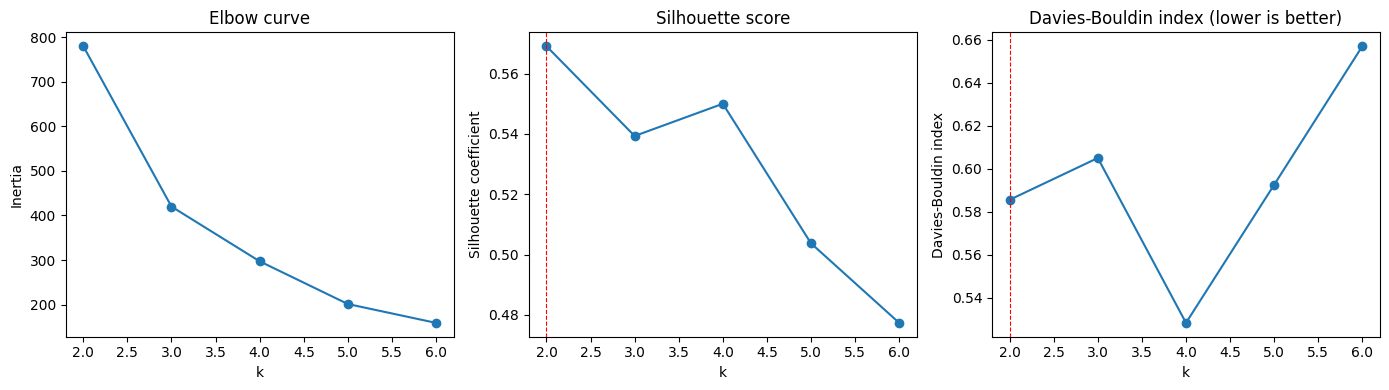

In [8]:
X_clust = score_matrix_norm

kmeans_results = {}
for k in KMEANS_K_RANGE:
    km      = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels  = km.fit_predict(X_clust)
    sil     = silhouette_score(X_clust, labels)
    db      = davies_bouldin_score(X_clust, labels)
    inertia = km.inertia_
    kmeans_results[k] = {"model": km, "labels": labels,
                         "silhouette": sil, "davies_bouldin": db, "inertia": inertia}
    print(f"  k={k}  silhouette={sil:.4f}  davies_bouldin={db:.4f}  inertia={inertia:.2f}")

best_k = max(kmeans_results, key=lambda k: kmeans_results[k]["silhouette"])
print(f"\nSelected k = {best_k} (highest silhouette = {kmeans_results[best_k]['silhouette']:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ks = list(kmeans_results.keys())

axes[0].plot(ks, [kmeans_results[k]["inertia"] for k in ks], marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow curve")

axes[1].plot(ks, [kmeans_results[k]["silhouette"] for k in ks], marker="o")
axes[1].axvline(best_k, color="red", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette coefficient")
axes[1].set_title("Silhouette score")

axes[2].plot(ks, [kmeans_results[k]["davies_bouldin"] for k in ks], marker="o")
axes[2].axvline(best_k, color="red", linestyle="--", linewidth=0.8)
axes[2].set_xlabel("k")
axes[2].set_ylabel("Davies-Bouldin index")
axes[2].set_title("Davies-Bouldin index (lower is better)")

plt.tight_layout()
plt.show()

## Assign Cluster Labels and Rename Clusters

Fit the final K-Means with the selected k. Clusters are renamed by their PNN detection rate in descending order: the cluster with the highest PNN rate is labelled **Spoofing** and the others are labelled **General** (sorted by decreasing overall anomaly severity).

In [9]:
kmeans_final = kmeans_results[best_k]["model"]
raw_labels   = kmeans_final.labels_

# Compute PNN detection rate per raw cluster
pnn_rates = {}
for c in range(best_k):
    mask          = raw_labels == c
    pnn_rates[c]  = preds_anom["pnn"][mask].mean() if mask.sum() > 0 else 0.0

# Sort clusters by PNN rate descending; highest PNN rate -> cluster 0 (renamed "Spoofing")
sorted_by_pnn = sorted(pnn_rates, key=pnn_rates.get, reverse=True)
remap          = {old: new for new, old in enumerate(sorted_by_pnn)}
cluster_labels = np.array([remap[c] for c in raw_labels])

# Build semantic names
cluster_names = {}
for new_c in range(best_k):
    old_c  = sorted_by_pnn[new_c]
    rate   = pnn_rates[old_c]
    if new_c == 0:
        cluster_names[new_c] = f"C0 - Spoofing-aligned (PNN rate={rate:.1%})"
    else:
        cluster_names[new_c] = f"C{new_c} - General anomaly {new_c}"

print("Cluster mapping (raw -> semantic):")
for new_c, name in cluster_names.items():
    old_c  = sorted_by_pnn[new_c]
    n_pts  = (cluster_labels == new_c).sum()
    print(f"  {name}  [n={n_pts}]")

Cluster mapping (raw -> semantic):
  C0 - Spoofing-aligned (PNN rate=2.0%)  [n=29738]
  C1 - General anomaly 1  [n=11529]


## Alternative Clustering Methods

HDBSCAN (Hierarchical DBSCAN) and Ward hierarchical clustering are fitted as references to validate the K-Means topology.

HDBSCAN is preferred over DBSCAN here because the anomaly score space contains clusters of unequal density: spoofing events tend to concentrate in a narrow region while general anomalies are more diffuse. DBSCAN's fixed epsilon fails when densities differ across clusters. HDBSCAN builds a full cluster hierarchy and extracts the most stable partitions, requiring only `min_cluster_size` and handling variable density natively.

In [10]:
try:
    from sklearn.cluster import HDBSCAN as _HDBSCAN
    _hdbscan_source = "sklearn"
except ImportError:
    import hdbscan as _hdbscan_lib
    _HDBSCAN = _hdbscan_lib.HDBSCAN
    _hdbscan_source = "hdbscan"
print(f"HDBSCAN source: {_hdbscan_source}")

from sklearn.metrics import adjusted_rand_score

# HDBSCAN: only min_cluster_size is required; adapts automatically to density variation
min_cluster_size = max(5, n_anom_total // 20)
hdbscan_model  = _HDBSCAN(min_cluster_size=min_cluster_size)
hdbscan_labels = hdbscan_model.fit_predict(X_clust)
n_hdb_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise        = (hdbscan_labels == -1).sum()
print(f"HDBSCAN (min_cluster_size={min_cluster_size}): {n_hdb_clusters} clusters, "
      f"{n_noise} noise points ({100 * n_noise / len(X_clust):.1f}%)")

mask_valid = hdbscan_labels != -1
if mask_valid.sum() >= 2 and n_hdb_clusters >= 2:
    sil_hdb = silhouette_score(X_clust[mask_valid], hdbscan_labels[mask_valid])
    print(f"HDBSCAN silhouette (excluding noise): {sil_hdb:.4f}")
else:
    print("HDBSCAN did not produce enough clusters for silhouette computation.")

# Hierarchical (Ward)
agg        = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels = agg.fit_predict(X_clust)
sil_agg    = silhouette_score(X_clust, agg_labels)
print(f"\nHierarchical Ward (k={best_k}) silhouette: {sil_agg:.4f}")

# Agreement between K-Means and Hierarchical
ari = adjusted_rand_score(cluster_labels, agg_labels)
print(f"Adjusted Rand Index (K-Means vs Hierarchical): {ari:.4f}")

# Agreement between K-Means and HDBSCAN (noise points excluded)
if n_hdb_clusters >= 2 and mask_valid.sum() > 0:
    ari_hdb = adjusted_rand_score(cluster_labels[mask_valid], hdbscan_labels[mask_valid])
    print(f"Adjusted Rand Index (K-Means vs HDBSCAN, excl. noise): {ari_hdb:.4f}")

HDBSCAN source: sklearn
HDBSCAN (min_cluster_size=2063): 2 clusters, 4944 noise points (12.0%)
HDBSCAN silhouette (excluding noise): 0.6740

Hierarchical Ward (k=2) silhouette: 0.5999
Adjusted Rand Index (K-Means vs Hierarchical): 0.5535
Adjusted Rand Index (K-Means vs HDBSCAN, excl. noise): 0.5806


## Score-Space Visualisation

### 2D PCA Projection

Project the 3-dimensional score vectors onto the first two principal components and colour-code by K-Means cluster. The PC explained-variance ratios indicate how much structure is captured in 2D.

PCA explained variance: PC1=0.909  PC2=0.075


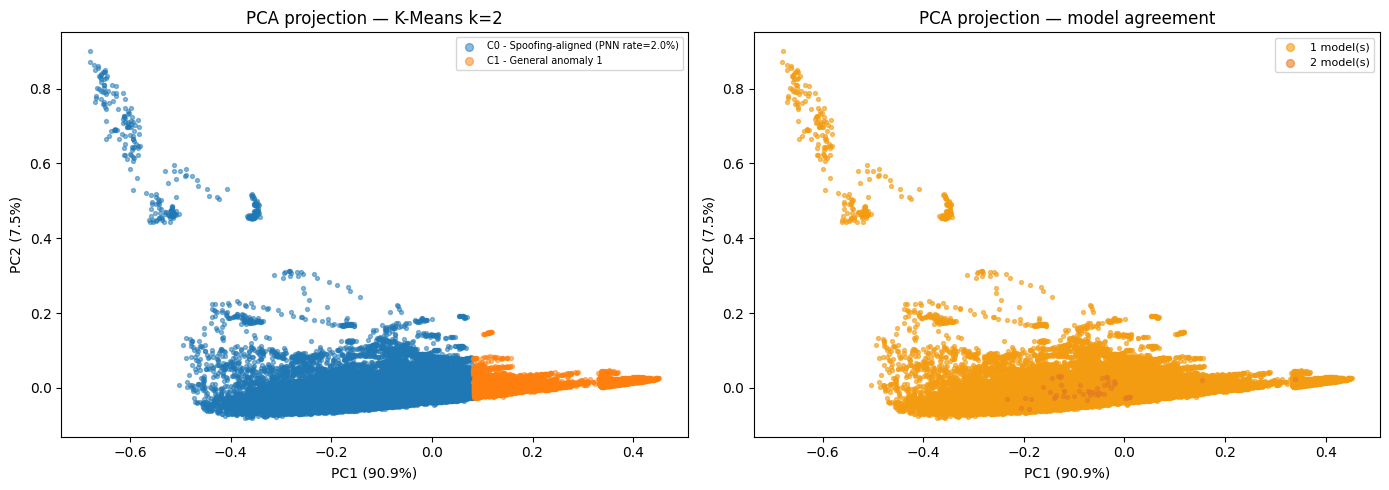

In [11]:
CLUSTER_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"][:best_k]

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_clust)
print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}  PC2={pca.explained_variance_ratio_[1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: K-Means clusters
for c in range(best_k):
    mask = cluster_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    s=8, alpha=0.5, color=CLUSTER_COLORS[c], label=cluster_names[c])
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_title(f"PCA projection — K-Means k={best_k}")
axes[0].legend(fontsize=7, markerscale=2)

# Right: model agreement
agreement_colors = {0: "#cccccc", 1: "#f39c12", 2: "#e67e22", 3: "#c0392b"}
n_flagged_anom   = n_models_flagged[anom_indices]
for n_models in sorted(set(n_flagged_anom)):
    mask = n_flagged_anom == n_models
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    s=8, alpha=0.6, color=agreement_colors[n_models],
                    label=f"{n_models} model(s)")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].set_title("PCA projection — model agreement")
axes[1].legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.show()

### t-SNE Projection

t-SNE gives a non-linear 2D embedding that may reveal tighter cluster boundaries. Since the input is 3D here, PCA pre-reduction is not needed.

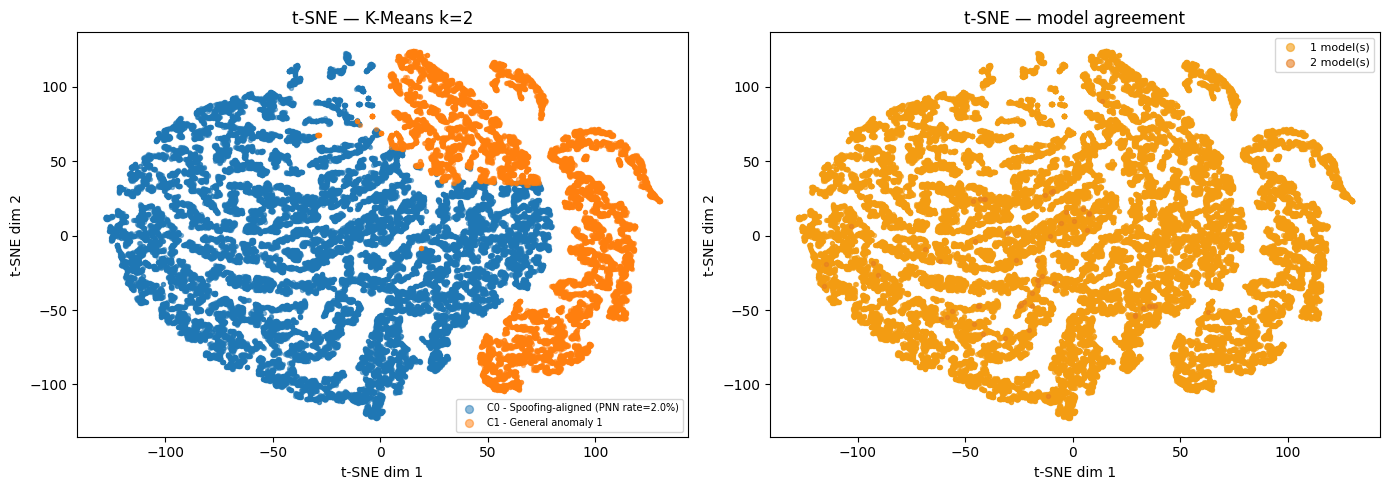

In [12]:
perplexity = min(30, max(5, n_anom_total // 10))
tsne       = TSNE(n_components=2, perplexity=perplexity, random_state=RANDOM_STATE,
                  init="pca", learning_rate="auto")
X_tsne     = tsne.fit_transform(X_clust)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for c in range(best_k):
    mask = cluster_labels == c
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    s=8, alpha=0.5, color=CLUSTER_COLORS[c], label=cluster_names[c])
axes[0].set_xlabel("t-SNE dim 1")
axes[0].set_ylabel("t-SNE dim 2")
axes[0].set_title(f"t-SNE - K-Means k={best_k}")
axes[0].legend(fontsize=7, markerscale=2)

for n_models in sorted(set(n_flagged_anom)):
    mask = n_flagged_anom == n_models
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    s=8, alpha=0.6, color=agreement_colors[n_models],
                    label=f"{n_models} model(s)")
axes[1].set_xlabel("t-SNE dim 1")
axes[1].set_ylabel("t-SNE dim 2")
axes[1].set_title("t-SNE - model agreement")
axes[1].legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.show()

### 3D Score Space

Direct visualisation of the original 3D score space, using each model's normalised score as an axis.

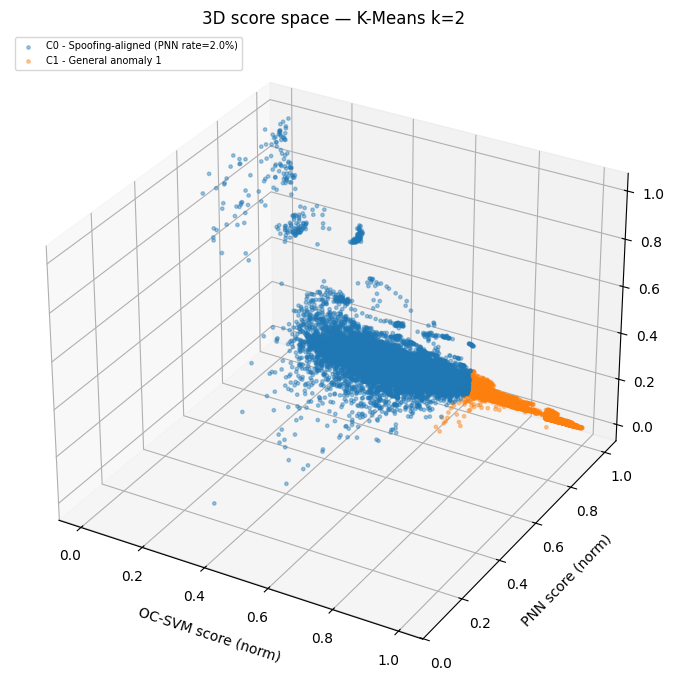

In [13]:
fig = plt.figure(figsize=(10, 7))
ax3d = fig.add_subplot(111, projection="3d")

for c in range(best_k):
    mask = cluster_labels == c
    ax3d.scatter(
        score_matrix_norm[mask, 0],
        score_matrix_norm[mask, 1],
        score_matrix_norm[mask, 2],
        s=6, alpha=0.4, color=CLUSTER_COLORS[c], label=cluster_names[c],
    )

ax3d.set_xlabel("OC-SVM score (norm)", labelpad=8)
ax3d.set_ylabel("PNN score (norm)", labelpad=8)
ax3d.set_zlabel("PRAE score (norm)", labelpad=8)
ax3d.set_title(f"3D score space — K-Means k={best_k}")
ax3d.legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()

## Cluster Profiling

For each cluster, report:
- Size and share of all anomalous samples.
- Mean normalised score per model.
- Detection rate per model (fraction of samples with `pred = 1`).
- Time-of-day distribution.

Cluster profile:


,N,Share (%),ocsvm_score_mean,ocsvm_det_rate,pnn_score_mean,pnn_det_rate,prae_score_mean,prae_det_rate
Cluster,,,,,,,,
C0 - Spoofing-aligned (PNN rate=2.0%),29738,72.06,0.4451,0.000,0.9853,0.0203,0.0589,0.9815
C1 - General anomaly 1,11529,27.94,0.8192,0.588,0.9988,0.0090,0.0177,0.4032


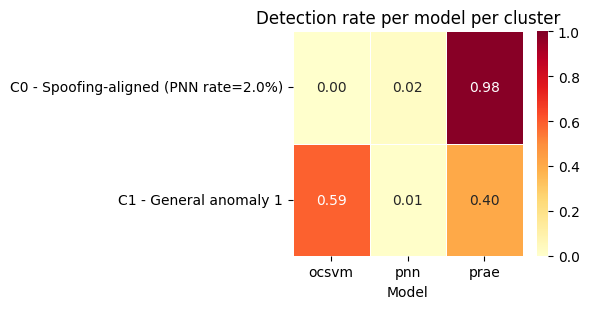

In [14]:
profile_rows = []
for c in range(best_k):
    mask = cluster_labels == c
    row  = {"Cluster": cluster_names[c], "N": int(mask.sum()),
            "Share (%)": round(100 * mask.sum() / n_anom_total, 2)}
    for j, mt in enumerate(MODEL_TYPES):
        short = mt.replace("transformer_ocsvm", "ocsvm")
        row[f"{short}_score_mean"] = round(float(score_matrix_norm[mask, j].mean()), 4)
        row[f"{short}_det_rate"]   = round(float(preds_anom[mt][mask].mean()), 4)
    profile_rows.append(row)

profile_df = pd.DataFrame(profile_rows).set_index("Cluster")
print("Cluster profile:")
display(profile_df)

# Detection rate heatmap
det_cols = [c for c in profile_df.columns if c.endswith("_det_rate")]
det_df   = profile_df[det_cols].rename(
    columns={c: c.replace("_det_rate", "") for c in det_cols}
)
fig, ax = plt.subplots(figsize=(6, 0.6 * best_k + 2))
sns.heatmap(det_df.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Detection rate per model per cluster")
ax.set_xlabel("Model")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Time-of-Day Distribution by Cluster

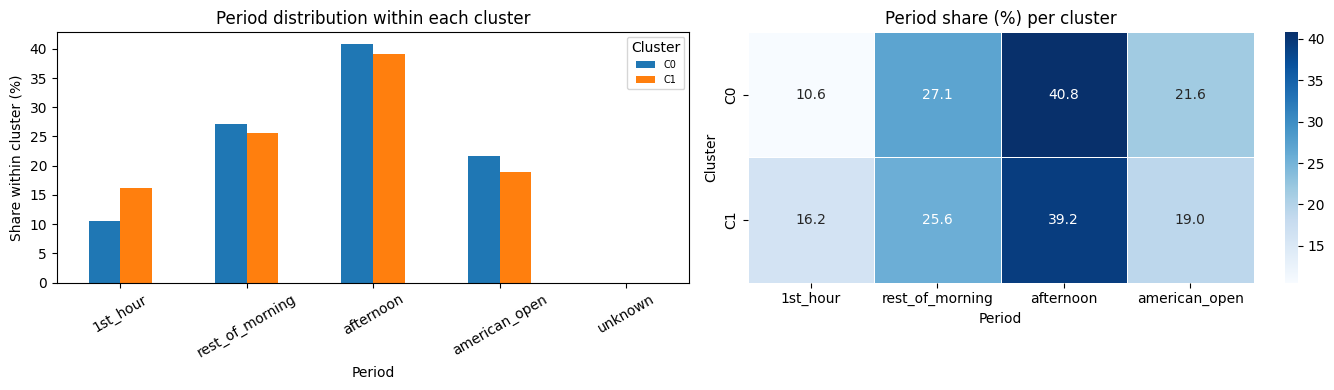

In [15]:
period_order = list(PERIODS.keys()) + ["unknown"]

period_matrix = np.zeros((best_k, len(period_order)), dtype=int)
for c in range(best_k):
    mask = cluster_labels == c
    for pi, p in enumerate(period_order):
        period_matrix[c, pi] = (period_anom[mask] == p).sum()

period_count_df = pd.DataFrame(
    period_matrix,
    index=[f"C{c}" for c in range(best_k)],
    columns=period_order,
)
period_pct_df = period_count_df.div(period_count_df.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

period_pct_df.T.plot(kind="bar", ax=axes[0], color=CLUSTER_COLORS)
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Share within cluster (%)")
axes[0].set_title("Period distribution within each cluster")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Cluster", fontsize=7)

sns.heatmap(period_pct_df.drop(columns=["unknown"], errors="ignore").astype(float),
            annot=True, fmt=".1f", cmap="Blues", ax=axes[1], linewidths=0.5)
axes[1].set_title("Period share (%) per cluster")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Cluster")

plt.tight_layout()
plt.show()

## Feature-Space Profiling

For each cluster, compute the mean feature vector over its anomalous samples and compare it against the mean over all anomalous samples. The top features by absolute normalised deviation identify which market microstructure signals drive each cluster.

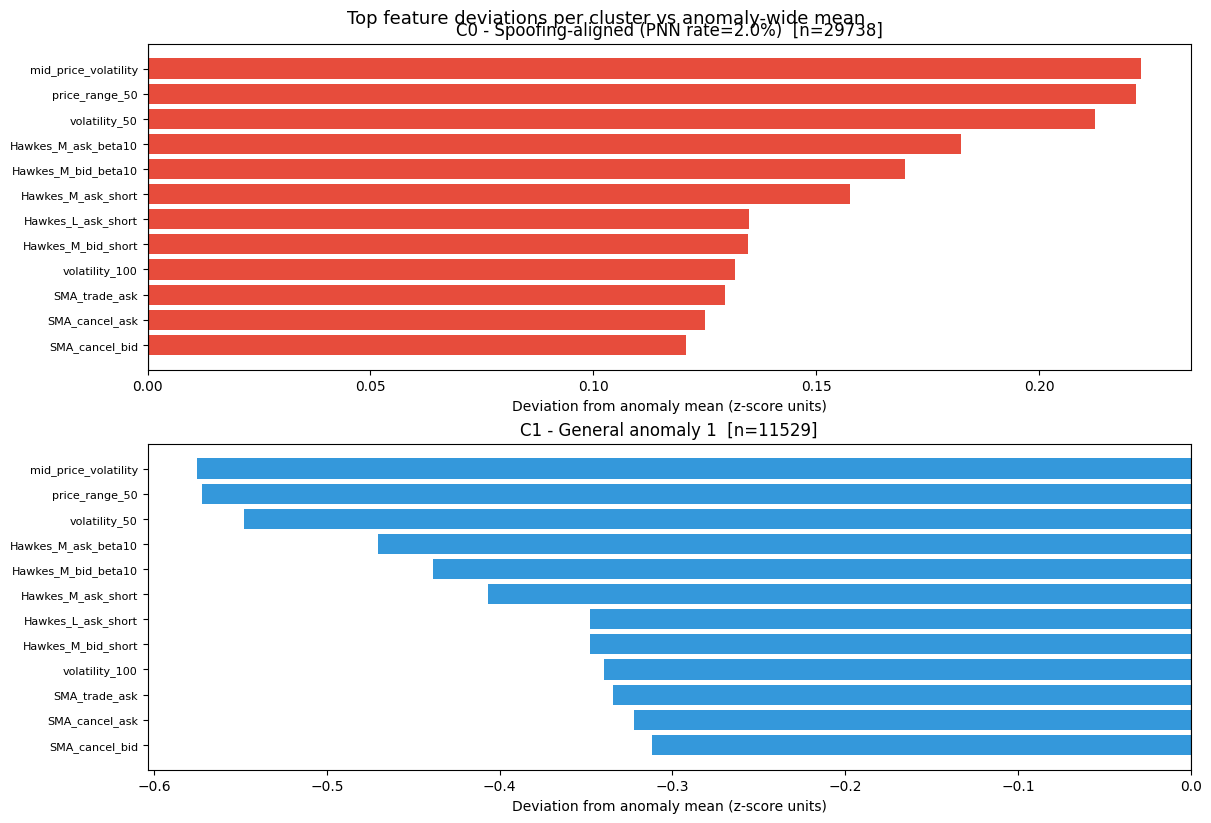

In [16]:
TOP_N_FEATURES = 12

global_mean = feat_anom.mean()
global_std  = feat_anom.std().replace(0, 1e-10)

fig, axes = plt.subplots(best_k, 1, figsize=(12, 4 * best_k), constrained_layout=True)
if best_k == 1:
    axes = [axes]

for c in range(best_k):
    mask      = cluster_labels == c
    c_feat    = feat_anom.iloc[mask]
    c_mean    = c_feat.mean()
    z_scores  = ((c_mean - global_mean) / global_std).abs().sort_values(ascending=False)
    top_feats = z_scores.head(TOP_N_FEATURES)

    deviation = (c_mean[top_feats.index] - global_mean[top_feats.index]) / global_std[top_feats.index]
    colors    = ["#e74c3c" if v > 0 else "#3498db" for v in deviation.values]

    axes[c].barh(range(TOP_N_FEATURES), deviation.values[::-1], color=colors[::-1])
    axes[c].set_yticks(range(TOP_N_FEATURES))
    axes[c].set_yticklabels(top_feats.index.tolist()[::-1], fontsize=8)
    axes[c].axvline(0, color="black", linewidth=0.8)
    axes[c].set_xlabel("Deviation from anomaly mean (z-score units)")
    axes[c].set_title(f"{cluster_names[c]}  [n={mask.sum()}]")

plt.suptitle("Top feature deviations per cluster vs anomaly-wide mean", fontsize=13, y=1.01)
plt.show()

## Feature-Space Clustering via PCA

Reduce the high-dimensional feature space to 10 principal components and run K-Means (same k). Comparing this clustering to the score-space clustering via ARI reveals whether the microstructure features alone reproduce the score-space partitioning.

Cumulative variance explained by 10 PCs: 0.612
Feature-space K-Means silhouette: 0.8725
ARI vs score-space clustering   : -0.0099


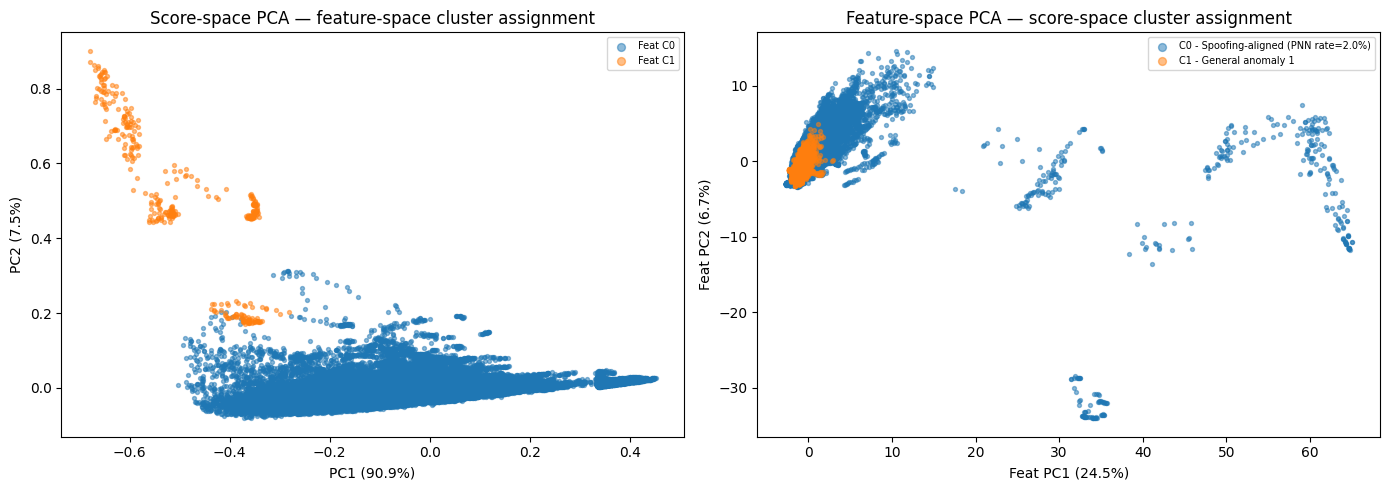

In [17]:
from sklearn.preprocessing import StandardScaler

N_PCA_COMPONENTS = min(10, feat_anom.shape[1])

feat_scaled = StandardScaler().fit_transform(feat_anom.values.astype(np.float32))
pca_feat    = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE)
X_feat_pca  = pca_feat.fit_transform(feat_scaled)
cumvar       = pca_feat.explained_variance_ratio_.cumsum()
print(f"Cumulative variance explained by {N_PCA_COMPONENTS} PCs: {cumvar[-1]:.3f}")

km_feat        = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
feat_labels    = km_feat.fit_predict(X_feat_pca)
sil_feat       = silhouette_score(X_feat_pca, feat_labels)
ari_feat_score = adjusted_rand_score(cluster_labels, feat_labels)
print(f"Feature-space K-Means silhouette: {sil_feat:.4f}")
print(f"ARI vs score-space clustering   : {ari_feat_score:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score-space PCA coloured by feature-space cluster
feat_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"][:best_k]
for c in set(feat_labels):
    mask = feat_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    s=8, alpha=0.5, color=feat_colors[c], label=f"Feat C{c}")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_title("Score-space PCA — feature-space cluster assignment")
axes[0].legend(fontsize=7, markerscale=2)

# Feature-space PCA coloured by score-space cluster
for c in range(best_k):
    mask = cluster_labels == c
    axes[1].scatter(X_feat_pca[mask, 0], X_feat_pca[mask, 1],
                    s=8, alpha=0.5, color=CLUSTER_COLORS[c], label=cluster_names[c])
axes[1].set_xlabel(f"Feat PC1 ({pca_feat.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"Feat PC2 ({pca_feat.explained_variance_ratio_[1]:.1%})")
axes[1].set_title("Feature-space PCA — score-space cluster assignment")
axes[1].legend(fontsize=7, markerscale=2)

plt.tight_layout()
plt.show()

## Score Distributions by Cluster

Violin plots of the normalised scores within each cluster, showing both the shape of the distribution and the interquartile range.

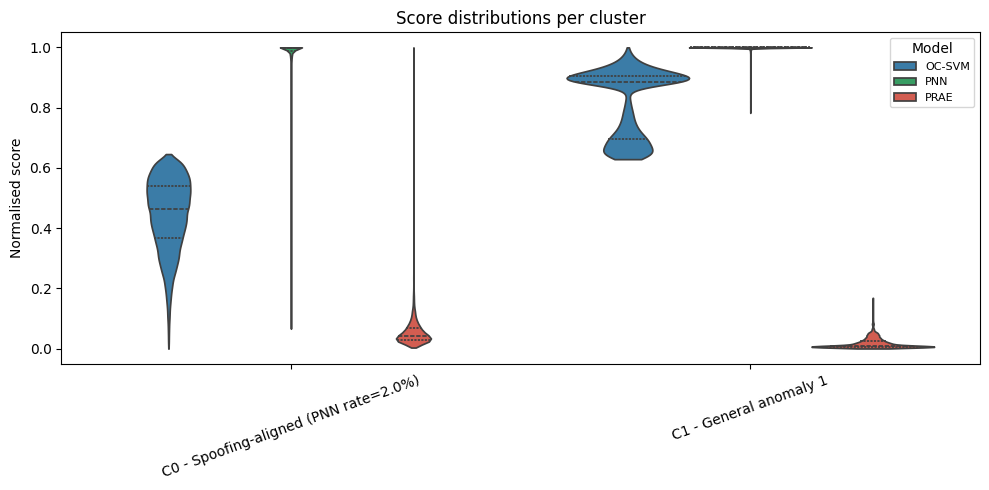

In [18]:
violin_df = pd.DataFrame(
    score_matrix_norm,
    columns=["OC-SVM", "PNN", "PRAE"],
)
violin_df["cluster"] = [cluster_names[c] for c in cluster_labels]
violin_long = violin_df.melt(id_vars="cluster", var_name="Model", value_name="Normalised score")

fig, ax = plt.subplots(figsize=(max(10, 3 * best_k), 5))
sns.violinplot(
    data=violin_long, x="cluster", y="Normalised score", hue="Model",
    split=False, inner="quartile", ax=ax, cut=0,
    palette=["#2980b9", "#27ae60", "#e74c3c"],
)
ax.set_xlabel("")
ax.set_ylabel("Normalised score")
ax.set_title("Score distributions per cluster")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Model", fontsize=8)
plt.tight_layout()
plt.show()

## Temporal Distribution of Clusters

Raw count of anomalous samples per cluster plotted over the sample index. Day boundaries (if multiple test files) are shown as vertical dashed lines.

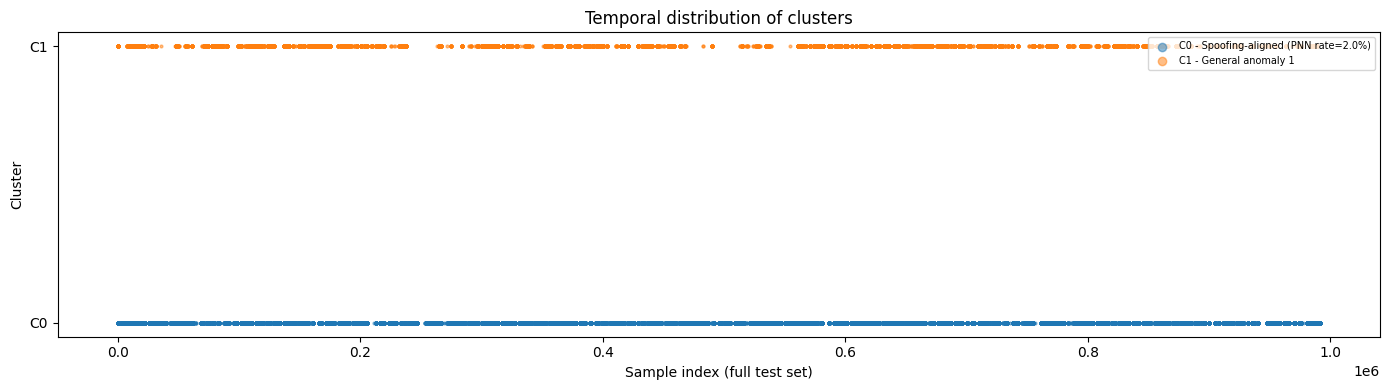

In [19]:
fig, ax = plt.subplots(figsize=(14, 4))

for c in range(best_k):
    mask    = cluster_labels == c
    t_idx   = anom_indices[mask]
    ax.scatter(t_idx, np.full(mask.sum(), c), s=4, alpha=0.5,
               color=CLUSTER_COLORS[c], label=cluster_names[c])

for b in day_boundaries[1:-1]:
    ax.axvline(b, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

ax.set_xlabel("Sample index (full test set)")
ax.set_ylabel("Cluster")
ax.set_yticks(range(best_k))
ax.set_yticklabels([f"C{c}" for c in range(best_k)])
ax.set_title("Temporal distribution of clusters")
ax.legend(fontsize=7, markerscale=3, loc="upper right")
plt.tight_layout()
plt.show()

## Summary Table

Consolidated view of all cluster characteristics.

In [20]:
summary_rows = []
for c in range(best_k):
    mask = cluster_labels == c
    n_c  = int(mask.sum())

    # Dominant period
    if mask.any():
        period_counts = pd.Series(period_anom[mask]).value_counts()
        dominant_period = period_counts.idxmax() if not period_counts.empty else "—"
    else:
        dominant_period = "—"

    # Top feature
    if mask.any() and feat_anom.shape[1] > 0:
        c_mean   = feat_anom.iloc[mask].mean()
        z_top    = ((c_mean - global_mean) / global_std).abs()
        top_feat = z_top.idxmax()
    else:
        top_feat = "—"

    # Interpretation hint
    pnn_rate = float(preds_anom["pnn"][mask].mean()) if mask.any() else 0.0
    ocsvm_rate = float(preds_anom["transformer_ocsvm"][mask].mean()) if mask.any() else 0.0
    prae_rate  = float(preds_anom["prae"][mask].mean()) if mask.any() else 0.0

    if pnn_rate >= 0.5:
        hint = "spoofing-type"
    elif ocsvm_rate >= 0.5 and prae_rate >= 0.5:
        hint = "general (OC-SVM + PRAE)"
    elif ocsvm_rate >= 0.5:
        hint = "general (OC-SVM driven)"
    elif prae_rate >= 0.5:
        hint = "general (PRAE driven)"
    else:
        hint = "marginal / mixed"

    summary_rows.append({
        "Cluster":        cluster_names[c],
        "N":              n_c,
        "Share (%)":      round(100 * n_c / n_anom_total, 2),
        "OC-SVM det.":    round(ocsvm_rate, 3),
        "PNN det.":       round(pnn_rate, 3),
        "PRAE det.":      round(prae_rate, 3),
        "Dominant period": dominant_period,
        "Top feature":    top_feat,
        "Interpretation": hint,
    })

summary_df = pd.DataFrame(summary_rows).set_index("Cluster")
pd.set_option("display.max_colwidth", 60)
display(summary_df)

,N,Share (%),OC-SVM det.,PNN det.,PRAE det.,Dominant period,Top feature,Interpretation
Cluster,,,,,,,,
C0 - Spoofing-aligned (PNN rate=2.0%),29738,72.06,0.000,0.020,0.981,afternoon,mid_price_volatility,general (PRAE driven)
C1 - General anomaly 1,11529,27.94,0.588,0.009,0.403,afternoon,mid_price_volatility,general (OC-SVM driven)
